In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


# Параметры модели

In [2]:
NUM_NODES    = 9
NUM_FEATURES = 4 
WINDOW_SIZE  = 72
STEP_SIZE    = 1  

HIDDEN_DIM   = 128
NUM_LAYERS   = 6
DROPOUT      = 0.2

BATCH_SIZE   = 512#32
EPOCHS       = 1000
LR           = 1e-3
WEIGHT_DECAY = 5e-4
PATIENCE     = 50  

MODEL_SAVE_NAME = 'stid_best.pt'

# Загрузка и предобработка данных

In [ ]:
import re
import numpy as np
import pandas as pd
from pathlib import Path

DATA_PATH = "data/predicted.csv"

DATE_COL = "DATE"
TARGET_COL = "Target"
DATE_FORMAT = "%y-%m-%d %H:%M:%S%z"
WT_SUFFIX_PATTERN = r"(.+)_WT(\d+)$"


def load_table(path):
    df = pd.read_csv(path)
    df2 = pd.read_csv("data/no_degrees_v2.csv")
    df["Target"] =df2["Target"]
    cols = [c for c in df.columns if c.startswith('NSPG_') or c.startswith("Target") or c.startswith("DAT") 
            or c.startswith('ENVT_') or c.startswith("HRWSPD_") or c.startswith("HRWD_")]
    return df[cols]


def detect_wt_columns(columns):
    rows = []
    pattern = re.compile(WT_SUFFIX_PATTERN)
    for col in columns:
        match = pattern.match(str(col))
        if not match:
            continue

        feature_name = match.group(1)
        node_id = int(match.group(2))

        rows.append({
            "column": col,
            "feature": feature_name,
            "node": node_id,
        })

    mapping = pd.DataFrame(rows)
    return mapping


df = load_table(DATA_PATH).copy()
df.columns = [str(col).strip() for col in df.columns]

df[DATE_COL]=pd.to_datetime(df[DATE_COL], format=DATE_FORMAT, errors="coerce", utc=True)
df = df.sort_values(DATE_COL).reset_index(drop=True)

for col in df.columns:
    if col != DATE_COL:
        df[col] = pd.to_numeric(df[col], errors="coerce")

numeric_cols = df.select_dtypes(include=[np.number]).columns

mapping = detect_wt_columns(df.columns)

node_ids = sorted(mapping["node"].unique())

features_by_node = {
    node: set(mapping.loc[mapping["node"] == node, "feature"])
    for node in node_ids
}
node_feature_names = sorted(set.intersection(*features_by_node.values()))

node_data = np.empty(
    (len(df), len(node_ids), len(node_feature_names)),
    dtype=np.float32,
)

for node_idx, node in enumerate(node_ids):
    for feature_idx, feature in enumerate(node_feature_names):
        col = f"{feature}_WT{node}"
        node_data[:, node_idx, feature_idx] = df[col].to_numpy(dtype=np.float32)
        
targets = df[TARGET_COL].to_numpy(dtype=np.float32)
timestamps = df[DATE_COL].copy() if DATE_COL is not None else pd.Series(np.arange(len(df)))

NUM_NODES_DATA = len(node_ids)
NUM_FEAT_RAW = len(node_feature_names)
NUM_NODES = NUM_NODES_DATA
NUM_FEATURES = NUM_FEAT_RAW

print(f"nodes      : {node_ids}")
print(f"features   : {len(node_feature_names)}")
print(f"node_data  : {node_data.shape}  (T, N, F)")
print(f"targets    : {targets.shape}")

DATA_PATH  : data/predicted_NSPG.csv
DATE_COL   : DATE
TARGET_COL : Target
nodes      : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
features   : 4
node_data  : (17544, 9, 4)  (T, N, F)
targets    : (17544,)


# Нормализация на Train и загрузчик датасета

In [6]:
T_len, N_nodes, N_feat = node_data.shape
split1 = int(0.70 * T_len)
split2 = int(0.85 * T_len)

scalers_X = [[StandardScaler() for _ in range(N_feat)] for _ in range(N_nodes)]
norm_data  = node_data.copy().astype(np.float32)
for ni in range(N_nodes):
    for fi in range(N_feat):
        scalers_X[ni][fi].fit(node_data[:split1, ni, fi].reshape(-1, 1))
        norm_data[:, ni, fi] = scalers_X[ni][fi].transform(
            node_data[:, ni, fi].reshape(-1, 1)).ravel()

scaler_y = StandardScaler()
scaler_y.fit(targets[:split1].reshape(-1, 1))
norm_tgt = scaler_y.transform(targets.reshape(-1, 1)).ravel().astype(np.float32)

class WindowDataset(Dataset):
    
    def __init__(self, data: np.ndarray, labels: np.ndarray,
                 window: int = WINDOW_SIZE, step: int = STEP_SIZE,
                 noise_std: float = 0.0):
        xs, ys = [], []
        for s in range(0, len(labels) - window + 1, step):
            xs.append(data[s : s + window])
            ys.append(labels[s + window - 1])
        self.xs = np.asarray(xs, dtype=np.float32)
        self.ys = np.asarray(ys, dtype=np.float32)
        self.noise_std = noise_std

    def __len__(self): return len(self.ys)
    def __getitem__(self, i):
        x = torch.tensor(self.xs[i])
        if self.noise_std > 0:
            x = x + torch.randn_like(x) * self.noise_std
        return x, torch.tensor(self.ys[i])

train_ds = WindowDataset(norm_data[:split1],          norm_tgt[:split1],          noise_std=0.02)
val_ds   = WindowDataset(norm_data[split1:split2],    norm_tgt[split1:split2],    noise_std=0.0)
test_ds  = WindowDataset(norm_data[split2:],          norm_tgt[split2:],          noise_std=0.0)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)} окон")
xb, yb = train_ds[0]
print(f"x: {tuple(xb.shape)} (W, N, F),  y: scalar {yb.shape}")

train=12209, val=2561, test=2561 окон
x: (72, 9, 4) (W, N, F),  y: scalar torch.Size([])


# Архитетура STID

In [ ]:
class MLPBlock(nn.Module):
    def __init__(self, dim: int, dropout: float = 0.1):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(dim, dim * 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim * 2, dim),
        )
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        return self.norm(x + self.fc(x))


class STID(nn.Module):
    def __init__(self, num_nodes: int = NUM_NODES,
                 in_features: int = NUM_FEATURES,
                 window_size: int = WINDOW_SIZE,
                 hidden_dim: int  = HIDDEN_DIM,
                 num_layers: int  = NUM_LAYERS,
                 dropout: float   = DROPOUT):
        super().__init__()
        self.num_nodes   = num_nodes
        self.window_size = window_size

        self.input_proj = nn.Linear(in_features, hidden_dim)

        # Spatial ID
        self.node_emb = nn.Embedding(num_nodes, hidden_dim)

        # Temporal ID
        self.time_emb = nn.Embedding(window_size, hidden_dim)

        self.mlp_blocks = nn.Sequential(*[
            MLPBlock(hidden_dim, dropout) for _ in range(num_layers)
        ])

        self.node_attn = nn.Linear(hidden_dim, 1)

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: B, W, N, F
        B, W, N, F = x.shape

        h = self.input_proj(x)  # B, W, N, D

        node_ids = torch.arange(N, device=x.device)
        h = h + self.node_emb(node_ids)  # B, W, N, D

        # TID эмбеддинг 
        time_ids = torch.arange(W, device=x.device)
        h = h + self.time_emb(time_ids).unsqueeze(0).unsqueeze(2)  # B, W, N, D

        B_W_N = B * W * N
        h = self.mlp_blocks(h.view(B_W_N, -1)).view(B, W, N, -1)  # B, W, N, D

        h = h.mean(dim=1)  # B, N, D

        attn = torch.softmax(self.node_attn(h), dim=1)  # B, N, 1
        h    = (h * attn).sum(dim=1) # B, D

        return self.head(h).squeeze(-1)  # B,


model = STID(
    num_nodes   = NUM_NODES,
    in_features = NUM_FEATURES,
    window_size = WINDOW_SIZE,
    hidden_dim  = HIDDEN_DIM,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nОбучаемых параметров: {n_params:,}')

STID(
  (input_proj): Linear(in_features=4, out_features=128, bias=True)
  (node_emb): Embedding(9, 128)
  (time_emb): Embedding(72, 128)
  (mlp_blocks): Sequential(
    (0): MLPBlock(
      (fc): Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.2, inplace=False)
        (3): Linear(in_features=256, out_features=128, bias=True)
      )
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (1): MLPBlock(
      (fc): Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.2, inplace=False)
        (3): Linear(in_features=256, out_features=128, bias=True)
      )
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (2): MLPBlock(
      (fc): Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2)

# Цикл обучения

In [8]:
optimizer  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=30, min_lr=1e-5)
criterion  = nn.HuberLoss(delta=1.0)

history    = {'train': [], 'val': []}
best_val   = float('inf')
best_state = None
best_epoch = 0

ema_val    = None
EMA_ALPHA  = 0.15  

for epoch in range(1, EPOCHS + 1):
    # Train 
    model.train()
    running, mae_sum = 0.0, 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 3.0)
        optimizer.step()
        running  += loss.item() * len(yb)
        mae_sum  += torch.abs(pred - yb).sum().item()
    train_loss = running  / len(train_ds)
    train_mae  = mae_sum  / len(train_ds)

    # Val
    model.eval()
    vl, vm = 0.0, 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred   = model(xb)
            vl    += criterion(pred, yb).item() * len(yb)
            vm    += torch.abs(pred - yb).sum().item()
    val_loss = vl / len(val_ds)
    val_mae  = vm / len(val_ds)

    scheduler.step(val_loss)

    ema_val = val_loss if ema_val is None else EMA_ALPHA * val_loss + (1 - EMA_ALPHA) * ema_val
    if ema_val < best_val:
        best_val   = ema_val
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_epoch = epoch

    history['train'].append(train_loss)
    history['val'].append(val_loss)

    if epoch % 10 == 0 or epoch == 1:
        lr_now = scheduler.get_last_lr()[0]
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Train Huber: {train_loss:.4f} | Train MAE: {train_mae:.4f} | "
              f"Val Huber: {val_loss:.4f} | Val MAE: {val_mae:.4f} | LR: {lr_now:.2e}")

    if epoch - best_epoch > PATIENCE:
        print(f"\nEarly stop at epoch {epoch}  (best epoch={best_epoch}, best EMA val={best_val:.4f})")
        break

model.load_state_dict(best_state)
torch.save(best_state, MODEL_SAVE_NAME)
print(f"Сохранено → {MODEL_SAVE_NAME}")

Epoch   1/1000 | Train Huber: 0.3743 | Train MAE: 0.7530 | Val Huber: 0.2772 | Val MAE: 0.6431 | LR: 1.00e-03
Epoch  10/1000 | Train Huber: 0.1497 | Train MAE: 0.4192 | Val Huber: 0.1224 | Val MAE: 0.3423 | LR: 1.00e-03
Epoch  20/1000 | Train Huber: 0.1408 | Train MAE: 0.4005 | Val Huber: 0.1212 | Val MAE: 0.3441 | LR: 1.00e-03
Epoch  30/1000 | Train Huber: 0.1422 | Train MAE: 0.4028 | Val Huber: 0.1218 | Val MAE: 0.3567 | LR: 1.00e-03
Epoch  40/1000 | Train Huber: 0.1386 | Train MAE: 0.3979 | Val Huber: 0.1235 | Val MAE: 0.3432 | LR: 1.00e-03
Epoch  50/1000 | Train Huber: 0.1323 | Train MAE: 0.3879 | Val Huber: 0.1129 | Val MAE: 0.3231 | LR: 1.00e-03
Epoch  60/1000 | Train Huber: 0.1323 | Train MAE: 0.3888 | Val Huber: 0.1147 | Val MAE: 0.3400 | LR: 1.00e-03
Epoch  70/1000 | Train Huber: 0.1275 | Train MAE: 0.3795 | Val Huber: 0.1106 | Val MAE: 0.3227 | LR: 1.00e-03
Epoch  80/1000 | Train Huber: 0.1235 | Train MAE: 0.3730 | Val Huber: 0.1150 | Val MAE: 0.3322 | LR: 1.00e-03
Epoch  90/

# Оценка качества 

In [9]:
model.eval()
preds_all, true_all = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        pred = model(xb.to(device)).cpu().numpy()
        preds_all.extend(pred)
        true_all.extend(yb.numpy())

preds_orig = scaler_y.inverse_transform(np.array(preds_all).reshape(-1,1)).ravel()
true_orig  = scaler_y.inverse_transform(np.array(true_all).reshape(-1,1)).ravel()

mse  = np.mean((preds_orig - true_orig) ** 2)
rmse = np.sqrt(mse)
mae  = np.mean(np.abs(preds_orig - true_orig))
r2   = 1 - mse / np.var(true_orig)

print('=' * 42)
print(f'  Test RMSE : {rmse:.4f}')
print(f'  Test MAE  : {mae:.4f}')
print(f'  Test R²   : {r2:.4f}')
print('=' * 42)

  Test RMSE : 3.7417
  Test MAE  : 2.3460
  Test R²   : 0.8849


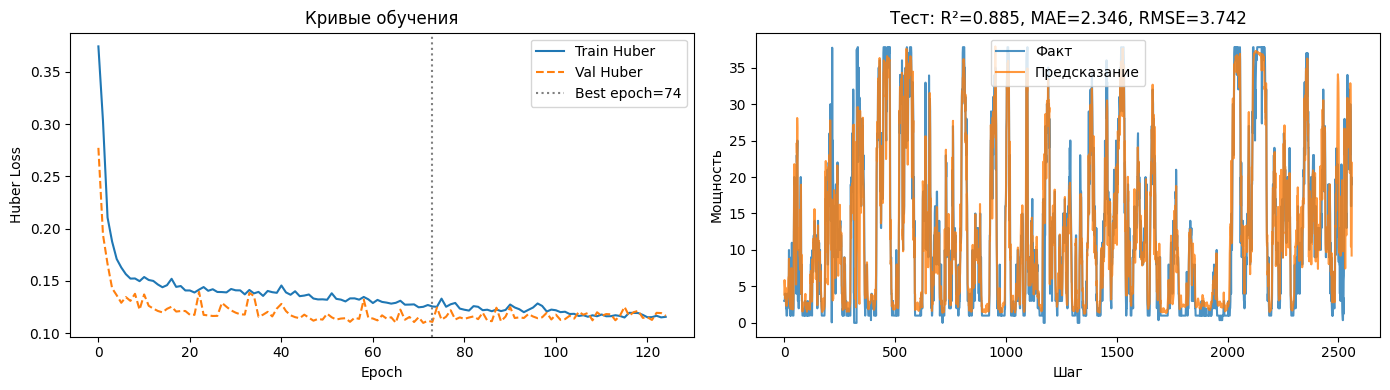

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# loss
axes[0].plot(history['train'], label='Train Huber')
axes[0].plot(history['val'],   label='Val Huber', linestyle='--')
axes[0].axvline(best_epoch - 1, color='gray', linestyle=':', label=f'Best epoch={best_epoch}')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Huber Loss')
axes[0].set_title('Кривые обучения'); axes[0].legend()

n_show = min(3000, len(true_orig))
axes[1].plot(true_orig[:n_show],  label='Факт',          alpha=0.8)
axes[1].plot(preds_orig[:n_show], label='Предсказание',  alpha=0.8)
axes[1].set_xlabel('Шаг'); axes[1].set_ylabel('Мощность')
axes[1].set_title(f'Тест: R²={r2:.3f}, MAE={mae:.3f}, RMSE={rmse:.3f}'); axes[1].legend()

plt.tight_layout()
plt.savefig(MODEL_SAVE_NAME.replace('.pt', '_results.png'), dpi=500, bbox_inches='tight')
plt.show()

Осредненная оценка по всем окнам
H=24  R²=0.885  MAE=2.3459  RMSE=3.7465  (n_windows=2537)
H=48  R²=0.885  MAE=2.3419  RMSE=3.7445  (n_windows=2513)
H=72  R²=0.887  MAE=2.3236  RMSE=3.7126  (n_windows=2489)


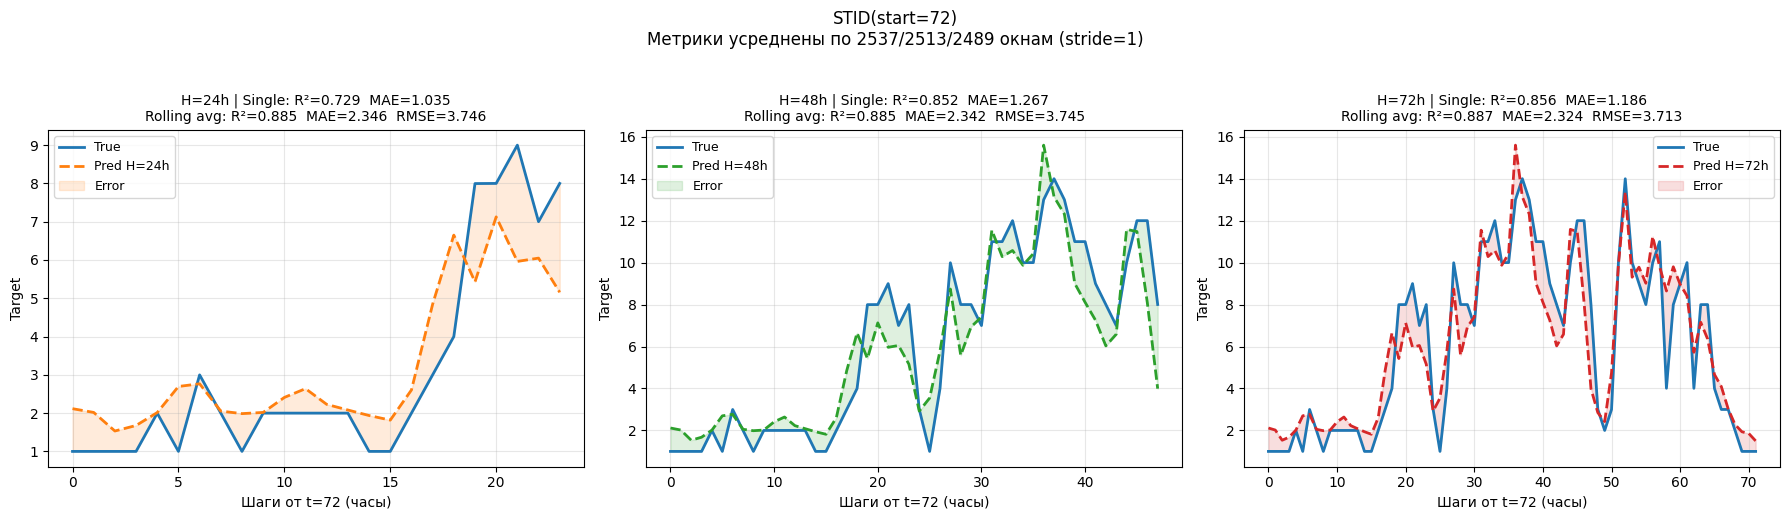

In [19]:
def predict_consecutive(horizon: int, startidx: int = None):
    test_data = norm_data[split2:]
    test_tgt  = norm_tgt[split2:]
    T_test    = len(test_tgt)

    if startidx is None:
        startidx = WINDOW_SIZE + 50

    assert startidx >= WINDOW_SIZE
    assert startidx + horizon <= T_test

    windows = np.stack(
        [test_data[startidx + step - WINDOW_SIZE : startidx + step]
         for step in range(horizon)],
        axis=0  
    )

    model.eval()
    with torch.no_grad():
        preds_norm = model(
            torch.tensor(windows, dtype=torch.float32).to(device)
        ).cpu().numpy()

    preds = scaler_y.inverse_transform(preds_norm.reshape(-1, 1)).ravel()
    trues = scaler_y.inverse_transform(
        test_tgt[startidx - 1 : startidx - 1 + horizon].reshape(-1, 1)
    ).ravel()
    return preds, trues


def evaluate_all_windows(horizon: int, stride: int = 1):

    test_data = norm_data[split2:]
    test_tgt  = norm_tgt[split2:]
    T_test    = len(test_tgt)

    start_min = WINDOW_SIZE          
    start_max = T_test - horizon      
    starts = range(start_min, start_max + 1, stride)

    all_preds = []
    all_trues = []

    for s in starts:
        p, t = predict_consecutive(horizon, startidx=s)
        all_preds.append(p)
        all_trues.append(t)

    all_preds = np.concatenate(all_preds)
    all_trues = np.concatenate(all_trues)

    mae  = np.mean(np.abs(all_preds - all_trues))
    rmse = np.sqrt(np.mean((all_preds - all_trues) ** 2))
    r2   = 1 - np.sum((all_preds - all_trues) ** 2) / np.sum((all_trues - np.mean(all_trues)) ** 2)
    mask = np.abs(all_trues) > 1e-6
    mape = np.mean(np.abs((all_preds[mask] - all_trues[mask]) / all_trues[mask])) * 100

    metrics = dict(mae=mae, rmse=rmse, r2=r2, mape=mape,
                   n_windows=len(starts))
    return metrics


START    = WINDOW_SIZE + 100
HORIZONS = [24, 48, 72]
COLORS   = ["tab:orange", "tab:green", "tab:red"]
STRIDE   = 1   

print("Осредненная оценка по всем окнам")
rolling_metrics = {}
for H in HORIZONS:
    m = evaluate_all_windows(H, stride=STRIDE)
    rolling_metrics[H] = m
    print(f"H={H}  R²={m['r2']:.3f}  MAE={m['mae']:.4f}  "
          f"RMSE={m['rmse']:.4f}  "
          f"(n_windows={m['n_windows']})")

#Визуализация для одного окна 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, H, color in zip(axes, HORIZONS, COLORS):
    res = consec_results[H]
    p, t = res["pred"], res["true"]
    x = np.arange(H)

    ax.plot(x, t, label="True",       color="tab:blue", lw=2)
    ax.plot(x, p, label=f"Pred H={H}h", color=color,  lw=2, linestyle="--")
    ax.fill_between(x, t, p, alpha=0.15, color=color, label="Error")

    m = rolling_metrics[H]
    ax.set_title(
        f"H={H}h | Single: R²={res['r2']:.3f}  MAE={res['mae']:.3f}\n"
        f"Rolling avg: R²={m['r2']:.3f}  MAE={m['mae']:.3f}  "
        f"RMSE={m['rmse']:.3f}",
        fontsize=10
    )
    ax.set_xlabel(f"Шаги от t={START-100} (часы)")
    ax.set_ylabel("Target")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle(
    f"STID(start={START-100})\n"
    f"Метрики усреднены по {rolling_metrics[24]['n_windows']}/"
    f"{rolling_metrics[48]['n_windows']}/{rolling_metrics[72]['n_windows']} окнам "
    f"(stride={STRIDE})",
    fontsize=12, y=1.03
)
plt.tight_layout()
plt.show()